In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
df = pd.read_csv('Loan_default.csv')

In [69]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [70]:
df.shape

(255347, 18)

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

In [72]:
print(df['Age'].max())
print(df['Age'].min())

69
18


In [73]:
age_range = [15, 25, 35, 45, 55, 65, 70]
df['Age_group'] = pd.cut(df['Age'], bins=age_range)
df = df.drop('Age', axis=1)

In [74]:
df.head()

,LoanID,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Age_group
0,I38PQUQS96,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0,"(55, 65]"
1,HPSK72WA7R,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0,"(65, 70]"
2,C1OZ6DPJ8Y,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1,"(45, 55]"
3,V2KKSFM3UN,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0,"(25, 35]"
4,EY08JDHTZP,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0,"(55, 65]"


In [75]:
df.shape

(255347, 18)

Loan Default with Age

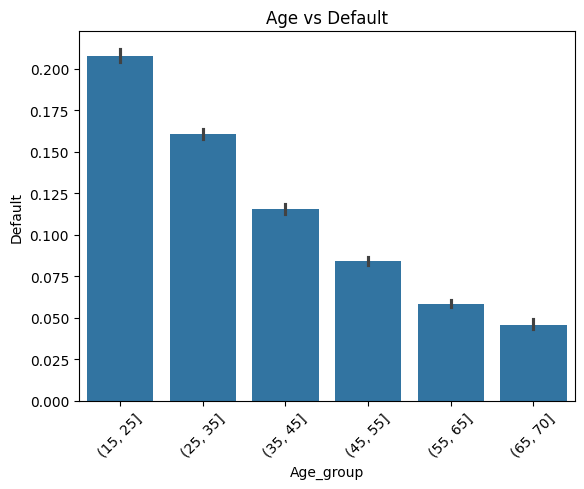

In [76]:
sns.barplot(x='Age_group', y='Default', data=df)
plt.xticks(rotation=45)
plt.title('Age vs Default')
plt.show()

From the above plot, we can identify that the person with in age 15-25 has done highest deffault

In [77]:
df.columns

Index(['LoanID', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
       'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
       'LoanPurpose', 'HasCoSigner', 'Default', 'Age_group'],
      dtype='str')

In [78]:
df = df.drop('LoanID', axis=1)

In [79]:
df.columns

Index(['Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
       'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
       'LoanPurpose', 'HasCoSigner', 'Default', 'Age_group'],
      dtype='str')

In [80]:
df.head()

,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Age_group
0,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0,"(55, 65]"
1,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0,"(65, 70]"
2,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1,"(45, 55]"
3,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0,"(25, 35]"
4,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0,"(55, 65]"


In [81]:
defaulter = df[df['Default'] == 1]
non_defaulter = df[df['Default'] == 0]        

In [82]:
col_list = list(df.columns)

In [83]:
col_list

['Income',
 'LoanAmount',
 'CreditScore',
 'MonthsEmployed',
 'NumCreditLines',
 'InterestRate',
 'LoanTerm',
 'DTIRatio',
 'Education',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage',
 'HasDependents',
 'LoanPurpose',
 'HasCoSigner',
 'Default',
 'Age_group']

In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   Income          255347 non-null  int64   
 1   LoanAmount      255347 non-null  int64   
 2   CreditScore     255347 non-null  int64   
 3   MonthsEmployed  255347 non-null  int64   
 4   NumCreditLines  255347 non-null  int64   
 5   InterestRate    255347 non-null  float64 
 6   LoanTerm        255347 non-null  int64   
 7   DTIRatio        255347 non-null  float64 
 8   Education       255347 non-null  str     
 9   EmploymentType  255347 non-null  str     
 10  MaritalStatus   255347 non-null  str     
 11  HasMortgage     255347 non-null  str     
 12  HasDependents   255347 non-null  str     
 13  LoanPurpose     255347 non-null  str     
 14  HasCoSigner     255347 non-null  str     
 15  Default         255347 non-null  int64   
 16  Age_group       255347 non-null  category
dtypes:

In [85]:
str_cols = []
for i in col_list:
    if df[i].dtype != 'int64' and i != 'Default':
        str_cols.append(i)

In [86]:
str_cols

['InterestRate',
 'DTIRatio',
 'Education',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage',
 'HasDependents',
 'LoanPurpose',
 'HasCoSigner',
 'Age_group']

In [87]:
df['Default'].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

<h3>Multivariate Analysis</h3>

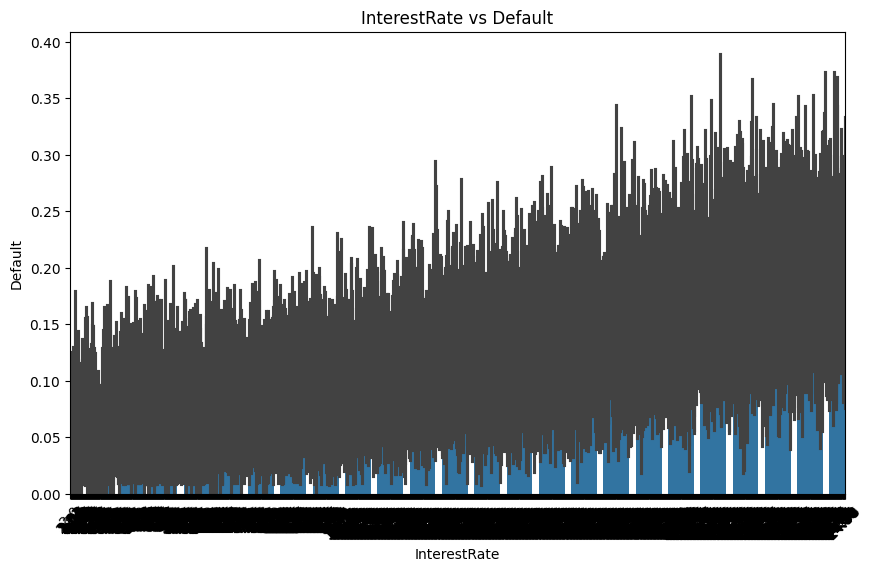

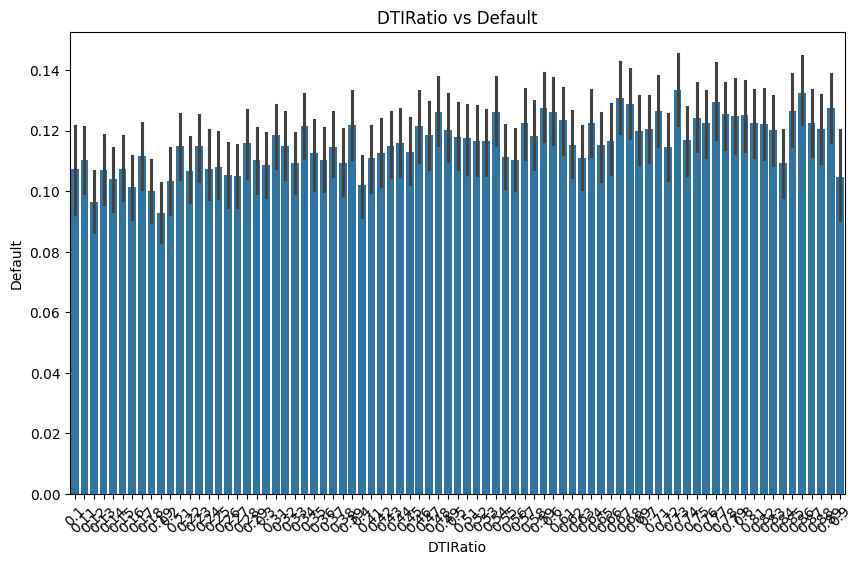

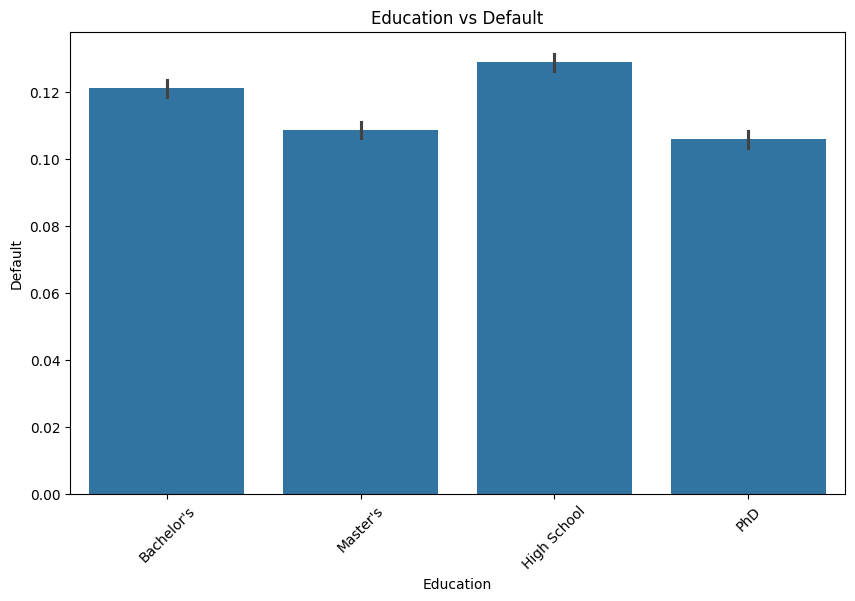

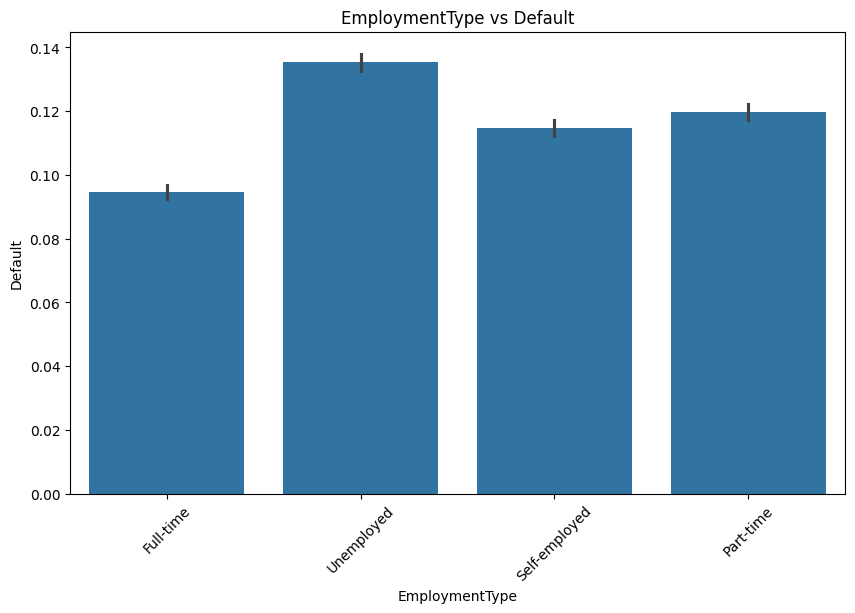

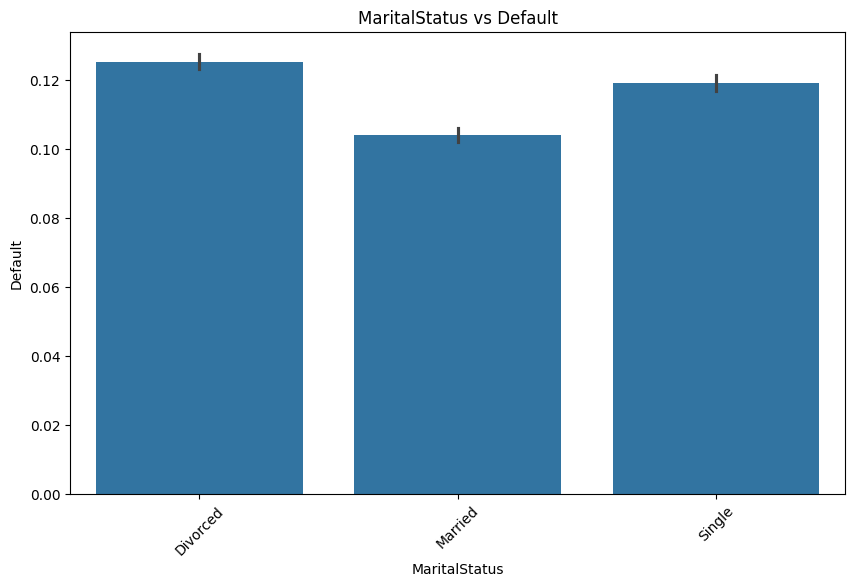

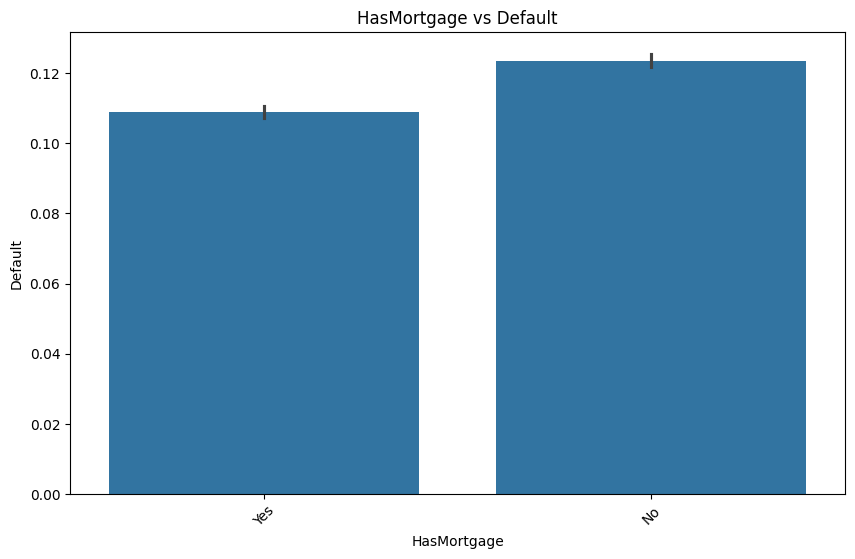

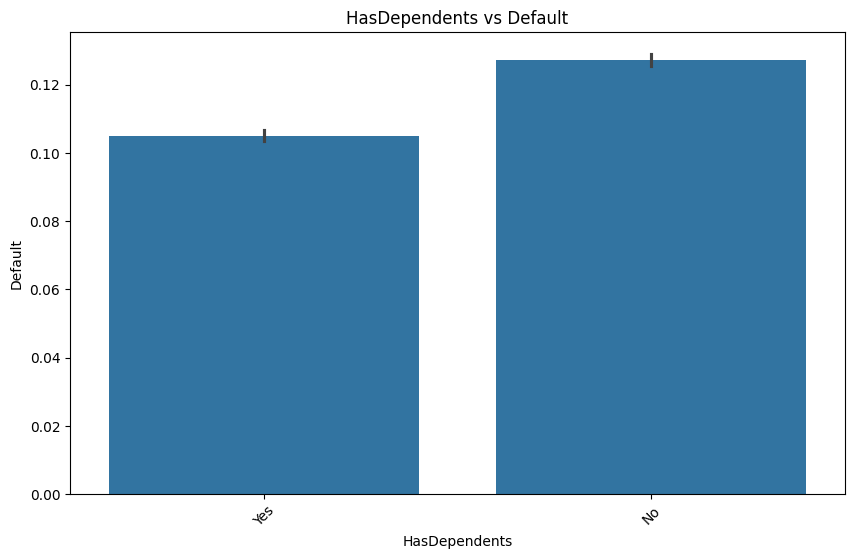

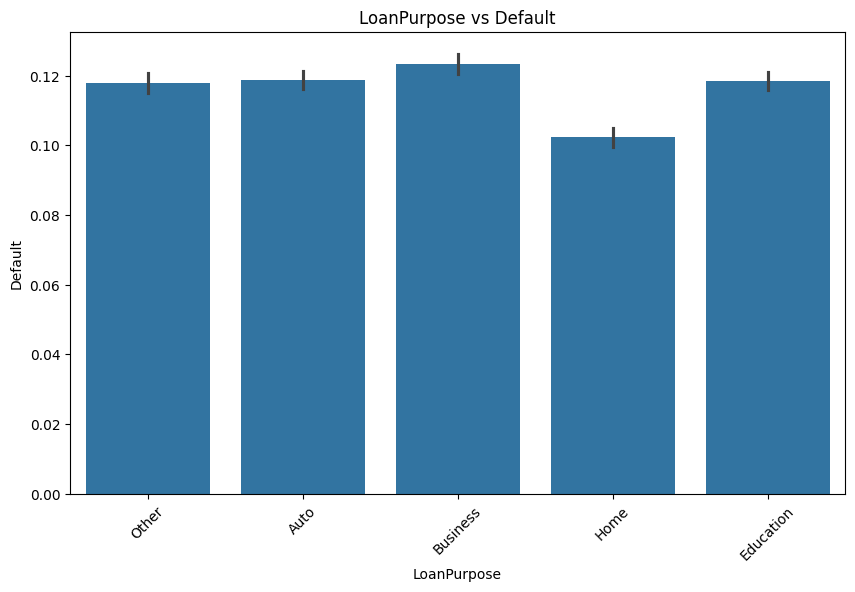

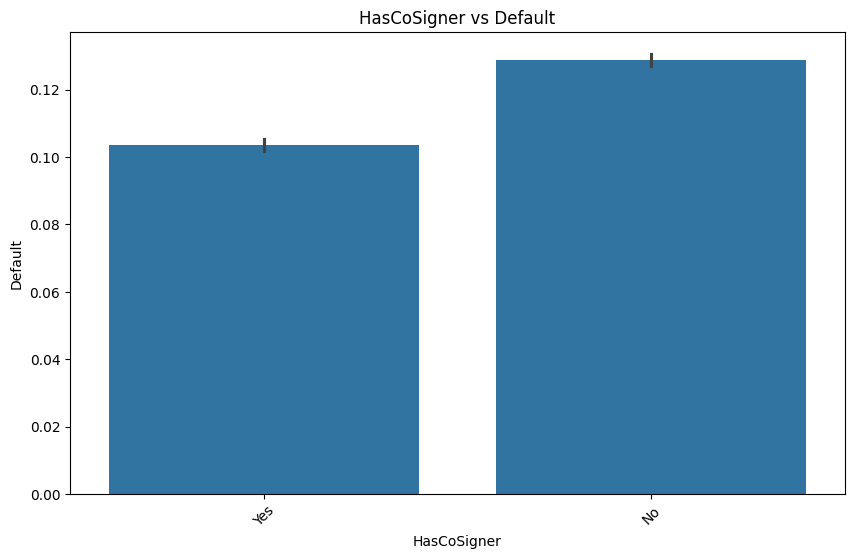

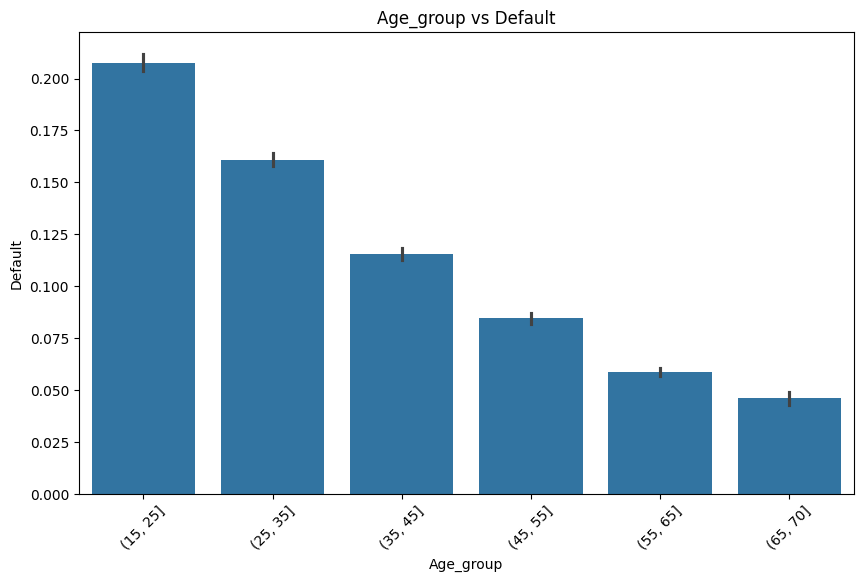

In [88]:
for col in str_cols:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=col, y=df['Default'] == 1, data=df)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Default')
    plt.show()

<p>From the above visuals, we can find:</p>
 <li>high schools student are high deffaulter in Education category</li>
 <li>Unemployed people are highest defulater in Employment type</li>
 <li>Divorced people are more defaulter in marital category</li>
 <li>People with no mortgage have higher deffault</li>
 <li>people with age group 15-25 are bigger deffaulter</li>
 <li>Business type loans have higher deffault rate</li>


In [89]:
col_list.remove('Default')

<h3>Univariate Analysis</h3>

C:\Users\lenovo\AppData\Local\Temp\ipykernel_4320\3597365065.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


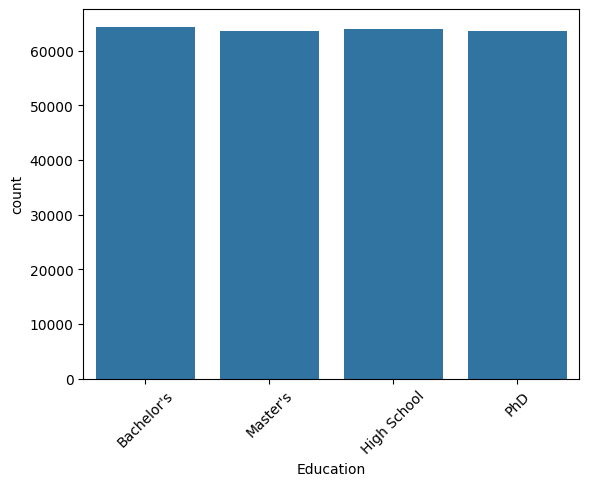

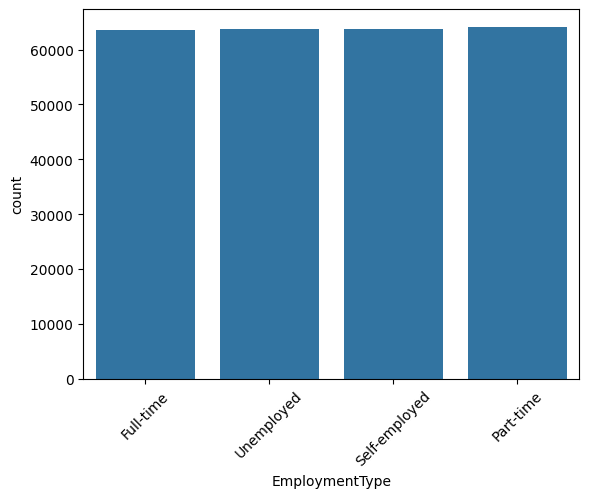

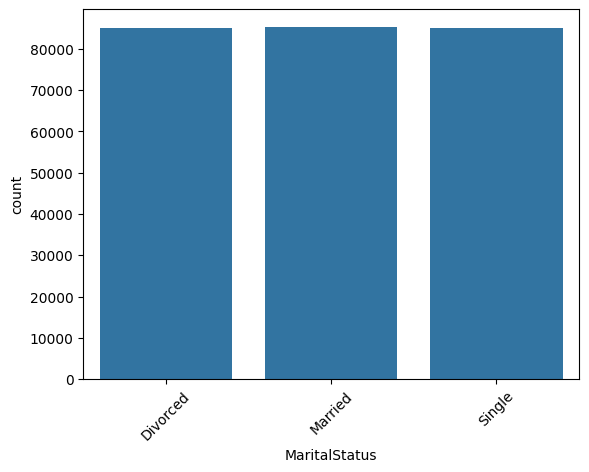

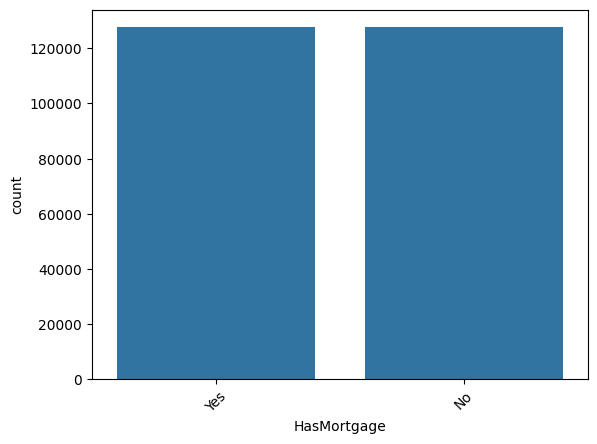

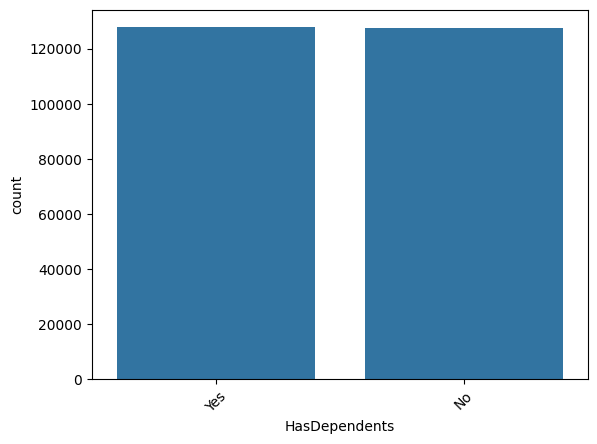

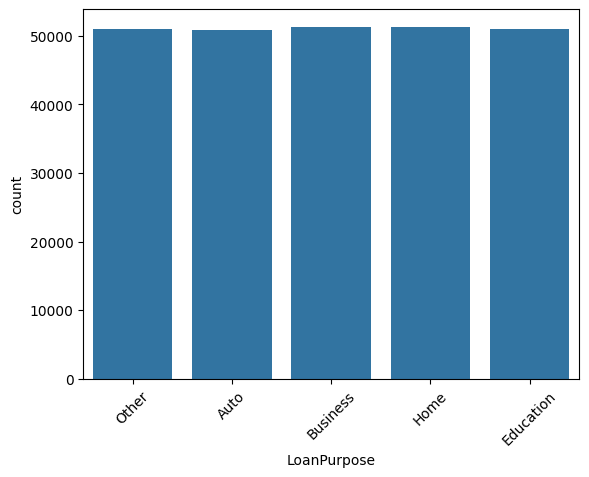

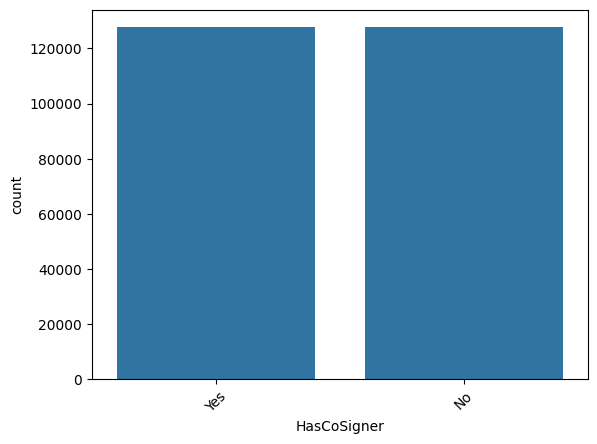

In [90]:
for col in df.select_dtypes(include='object').columns:
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.show()

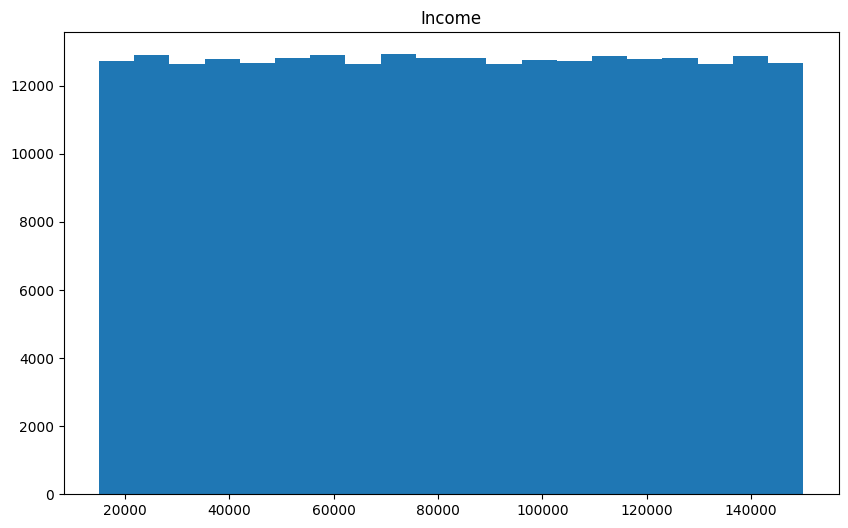

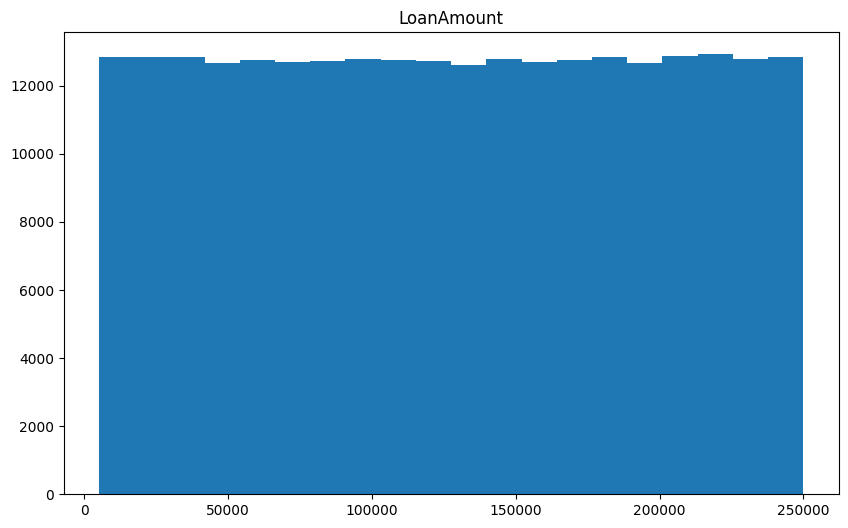

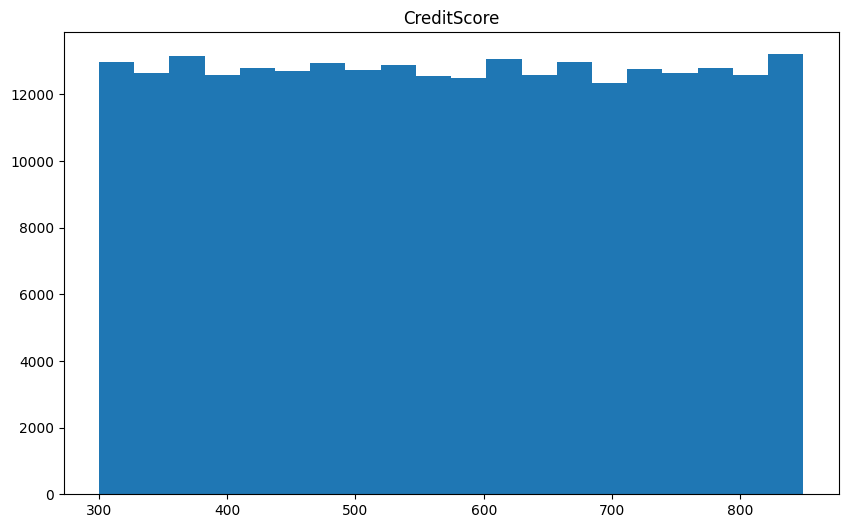

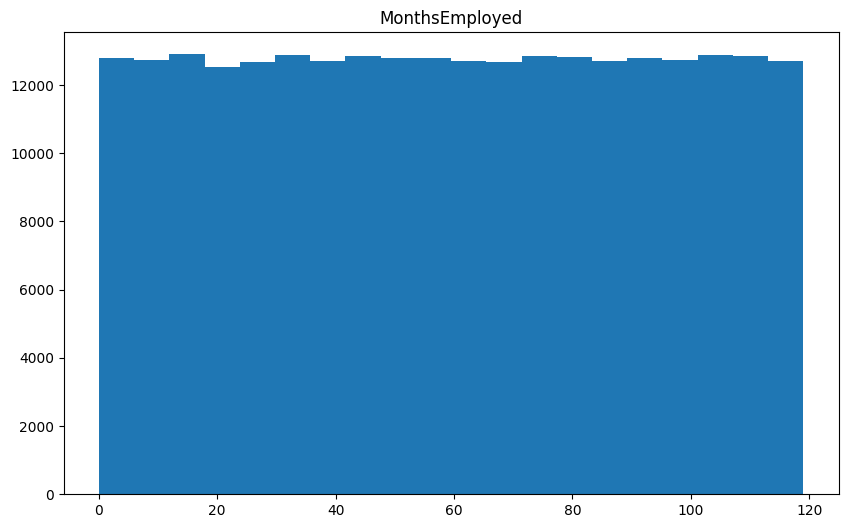

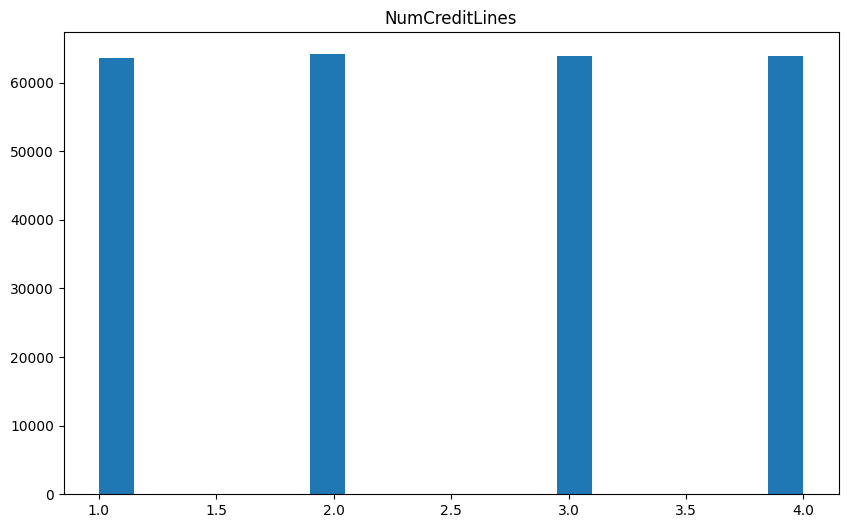

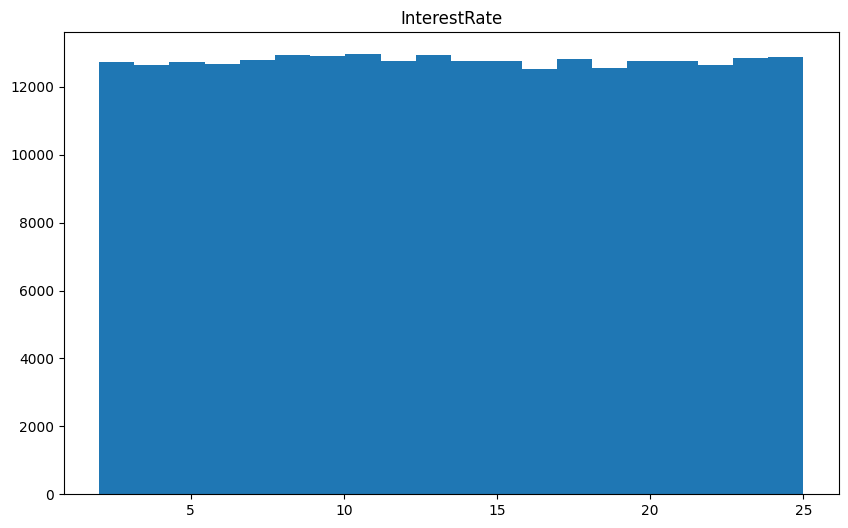

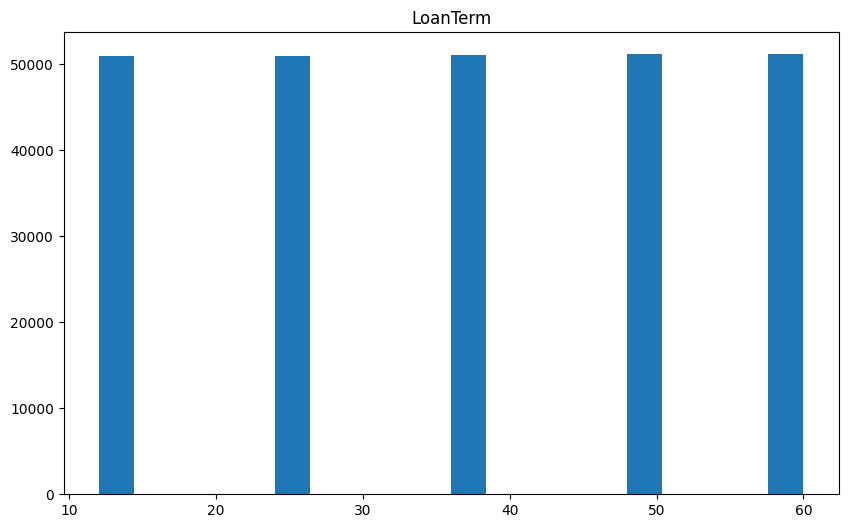

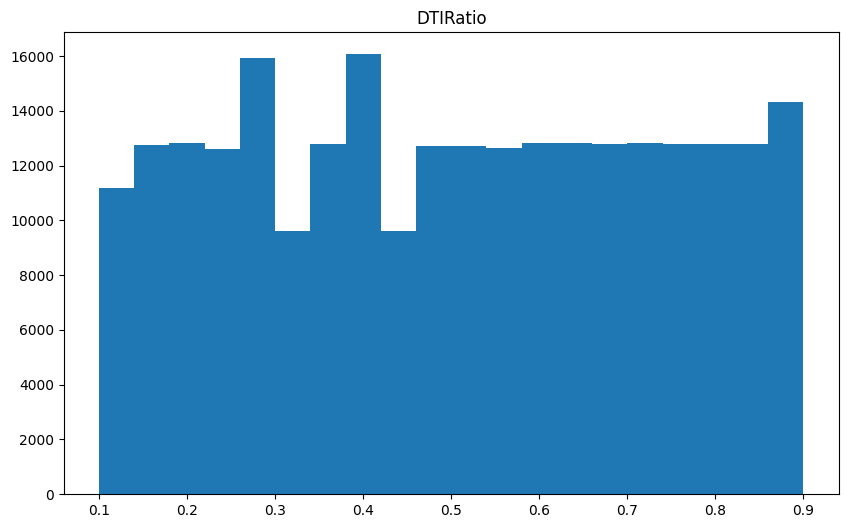

In [94]:
for col in col_list:
    if (df[col].dtypes == 'int64' or df[col].dtypes == 'float64'):
        plt.figure(figsize=(10, 6))
        plt.hist(x=df[col], bins=20)
        plt.title(col)
        plt.show()

In [49]:
df.describe(include='all')

,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Age_group
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347,255347,255347,255347,255347,255347,255347,255347.000000,255347
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4,3,2,2,5,2,NaN,6
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bachelor's,Part-time,Married,Yes,Yes,Business,Yes,NaN,"(25, 35]"
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64366,64161,85302,127677,127742,51298,127701,NaN,49408
mean,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.116128,NaN
std,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.320379,NaN
min,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
25%,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
50%,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
75%,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN


In [50]:
df.isnull().sum()

Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
Age_group         0
dtype: int64

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   Income          255347 non-null  int64   
 1   LoanAmount      255347 non-null  int64   
 2   CreditScore     255347 non-null  int64   
 3   MonthsEmployed  255347 non-null  int64   
 4   NumCreditLines  255347 non-null  int64   
 5   InterestRate    255347 non-null  float64 
 6   LoanTerm        255347 non-null  int64   
 7   DTIRatio        255347 non-null  float64 
 8   Education       255347 non-null  str     
 9   EmploymentType  255347 non-null  str     
 10  MaritalStatus   255347 non-null  str     
 11  HasMortgage     255347 non-null  str     
 12  HasDependents   255347 non-null  str     
 13  LoanPurpose     255347 non-null  str     
 14  HasCoSigner     255347 non-null  str     
 15  Default         255347 non-null  int64   
 16  Age_group       255347 non-null  category
dtypes:

<h3>Outliers Identification</h3>

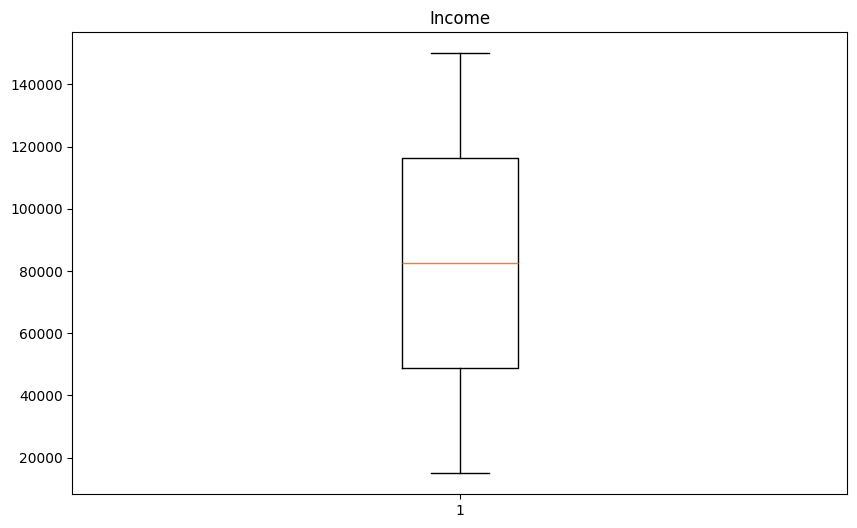

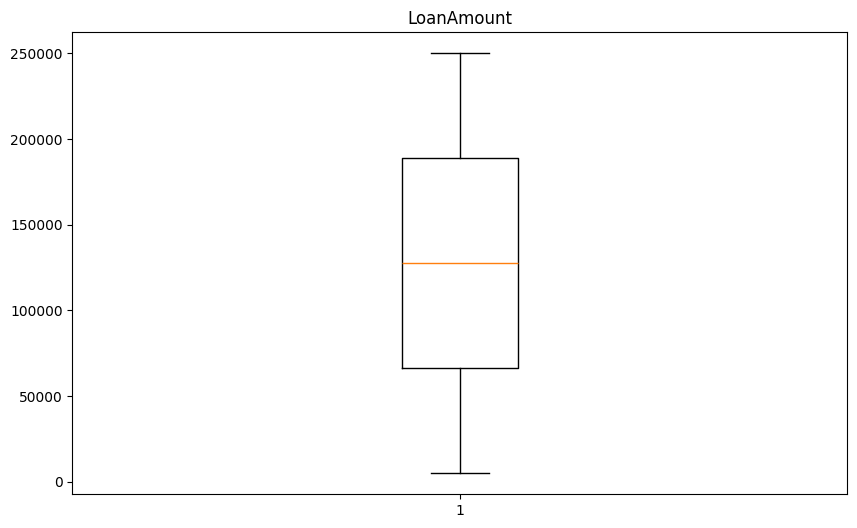

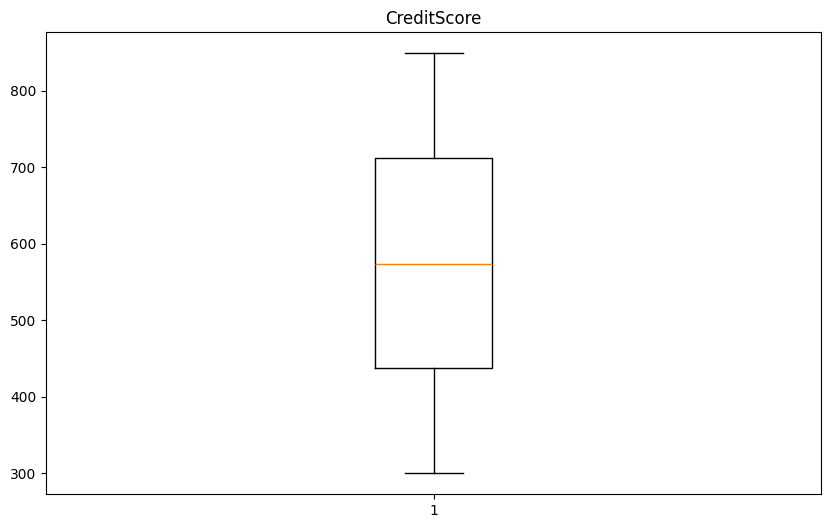

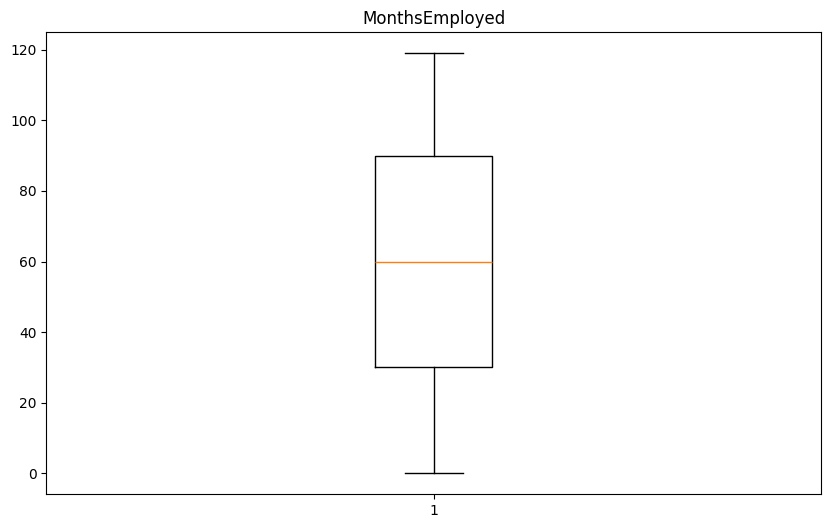

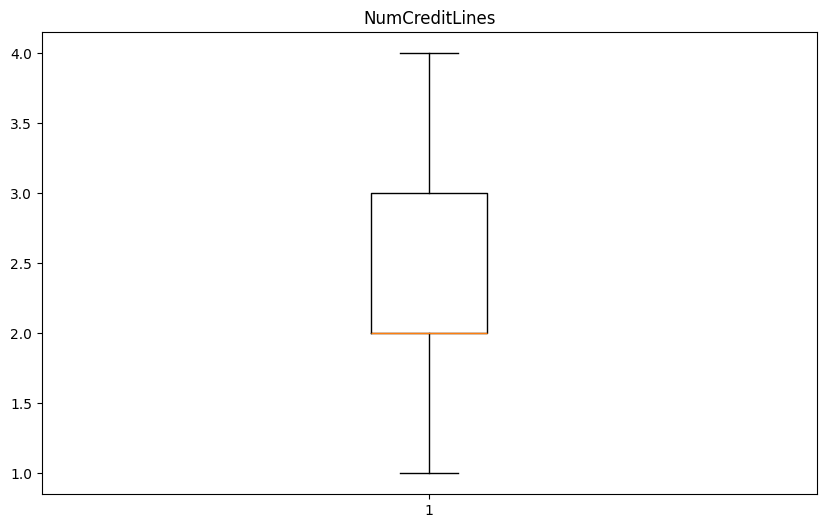

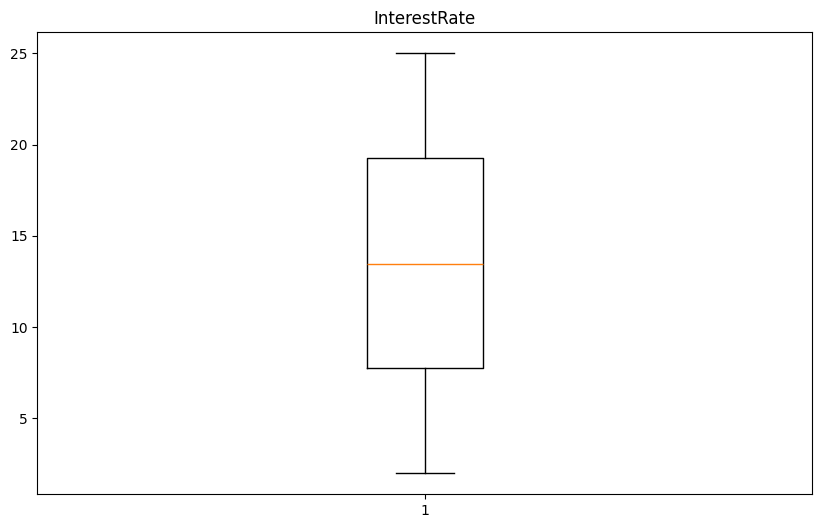

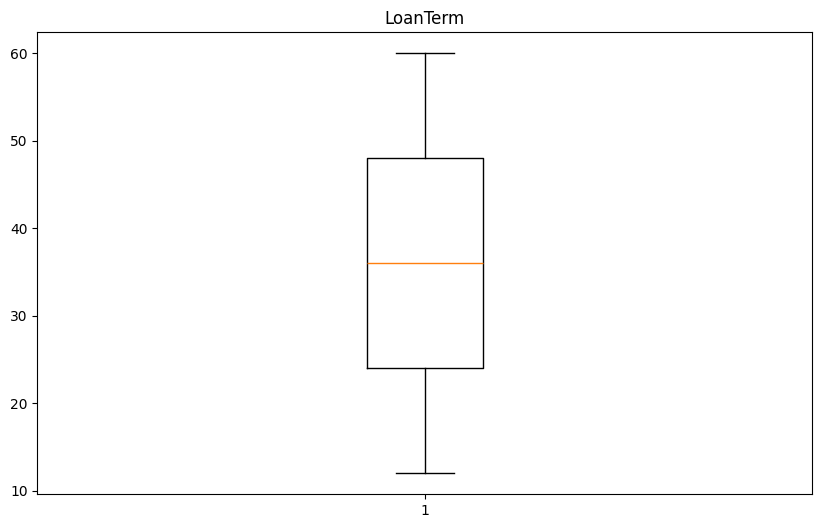

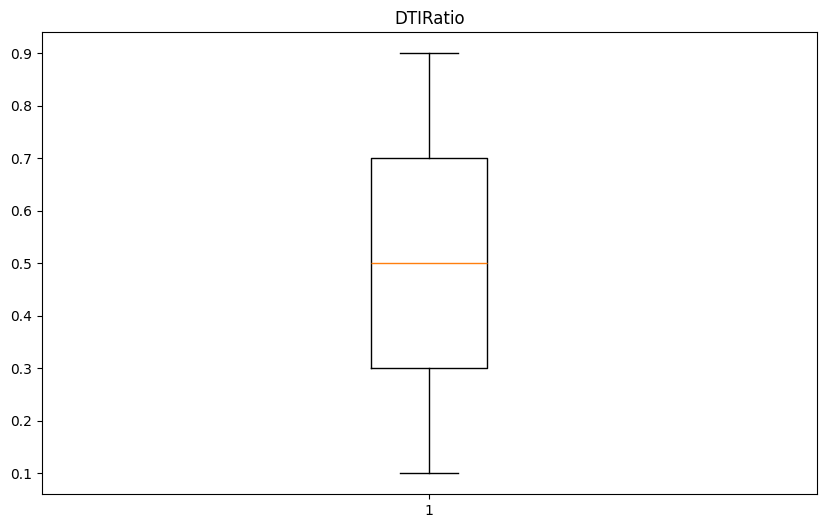

In [58]:
for col in col_list:
    if (df[col].dtypes == 'int64' or df[col].dtypes == 'float64'):
        plt.figure(figsize=(10, 6))
        plt.boxplot(x=df[col])
        plt.title(col)
        plt.show()

From the above boxplot, we cannot find any outliers in the above data

In [60]:
df.head(20)

,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Age_group
0,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0,"(55, 65]"
1,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0,"(65, 70]"
2,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1,"(45, 55]"
3,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0,"(25, 35]"
4,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0,"(55, 65]"
5,90298,90448,720,18,2,22.72,24,0.10,High School,Unemployed,Single,Yes,No,Business,Yes,1,"(15, 25]"
6,111188,177025,429,80,1,19.11,12,0.16,Bachelor's,Unemployed,Single,Yes,No,Home,Yes,0,"(35, 45]"
7,126802,155511,531,67,4,8.15,60,0.43,PhD,Full-time,Married,No,No,Home,Yes,0,"(55, 65]"
8,42053,92357,827,83,1,23.94,48,0.20,Bachelor's,Self-employed,Divorced,Yes,No,Education,No,1,"(35, 45]"
9,132784,228510,480,114,4,9.09,48,0.33,High School,Self-employed,Married,Yes,No,Other,Yes,0,"(35, 45]"


In [62]:
df.sort_values(by='LoanAmount').head(20)

,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Age_group
169381,99437,5000,538,89,3,16.96,12,0.45,Master's,Self-employed,Married,Yes,Yes,Home,Yes,1,"(35, 45]"
148043,106933,5001,656,98,1,3.30,24,0.86,Bachelor's,Part-time,Single,Yes,Yes,Education,No,0,"(35, 45]"
7095,44841,5005,755,31,3,14.09,24,0.49,Bachelor's,Full-time,Divorced,Yes,No,Education,Yes,0,"(55, 65]"
203247,42520,5006,665,84,3,7.29,60,0.35,Bachelor's,Full-time,Married,Yes,Yes,Education,Yes,0,"(55, 65]"
172983,131698,5009,494,51,4,5.11,12,0.11,Bachelor's,Unemployed,Single,No,No,Education,Yes,0,"(15, 25]"
112899,84890,5009,338,49,2,12.03,24,0.88,Master's,Part-time,Single,No,Yes,Education,Yes,0,"(55, 65]"
242990,142379,5012,305,90,3,8.34,24,0.70,Master's,Self-employed,Single,Yes,No,Business,Yes,0,"(35, 45]"
219744,148409,5012,672,35,2,22.49,24,0.46,Bachelor's,Part-time,Divorced,No,No,Education,Yes,1,"(25, 35]"
151263,64383,5012,581,50,2,24.48,36,0.46,Bachelor's,Unemployed,Married,No,Yes,Other,No,0,"(15, 25]"
12179,114734,5015,820,56,3,11.95,24,0.41,Bachelor's,Unemployed,Divorced,Yes,No,Education,No,0,"(15, 25]"


In [63]:
df.sort_values(by='LoanAmount').tail(20)

,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Age_group
157828,116315,249970,319,82,3,16.31,60,0.34,Master's,Full-time,Divorced,No,No,Business,Yes,0,"(55, 65]"
150824,90689,249972,810,95,4,24.39,48,0.71,Bachelor's,Self-employed,Single,Yes,No,Auto,No,0,"(25, 35]"
130346,60516,249973,464,14,2,7.62,24,0.78,Master's,Full-time,Divorced,No,Yes,Other,Yes,0,"(45, 55]"
59929,124930,249976,547,59,2,16.50,48,0.61,Bachelor's,Unemployed,Divorced,Yes,Yes,Education,No,0,"(15, 25]"
173266,108399,249976,482,69,2,5.42,36,0.84,Master's,Unemployed,Married,Yes,Yes,Auto,No,0,"(55, 65]"
237372,118283,249978,391,23,1,9.46,36,0.76,PhD,Full-time,Single,Yes,No,Business,Yes,0,"(45, 55]"
119236,34185,249981,588,94,2,9.27,36,0.58,PhD,Unemployed,Single,Yes,No,Auto,Yes,0,"(55, 65]"
85916,134916,249985,396,90,3,9.83,36,0.73,High School,Self-employed,Single,Yes,No,Education,Yes,0,"(45, 55]"
23223,48292,249986,738,33,3,18.54,36,0.71,Bachelor's,Unemployed,Divorced,No,No,Business,Yes,0,"(35, 45]"
218393,146186,249986,401,2,1,3.38,24,0.66,PhD,Unemployed,Single,No,No,Auto,Yes,0,"(25, 35]"
